# **Book Recommendation System**

### **About Project-**

Project Name - Books Recommendation System

Project Type - Content based Recommendation System

Contibutor - Individual

Name - Annu

### **Github Link -**

https://github.com/ianujrathore/GenerativeAI-and-AgenticAI/blob/main/Book_Recommendation_System_Project.ipynb

### **Know your Data**

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import difflib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Summer training 2026/DataSet 2026/book.csv")
df.head()

,Unnamed: 0,book_id,authors,original_publication_year,title,language_code,average_rating,image_url,description
0,0,2767052,Suzanne Collins,2008.0,"The Hunger Games (The Hunger Games, #1)",eng,4.34,https://images.gr-assets.com/books/1447303603m...,First in the ground-breaking HUNGER GAMES tril...
1,1,3,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,https://images.gr-assets.com/books/1474154022m...,Rescued from the outrageous neglect of his aun...
2,2,41865,Stephenie Meyer,2005.0,"Twilight (Twilight, #1)",en-US,3.57,https://images.gr-assets.com/books/1361039443m...,"When 17 year old Isabella Swan moves to Forks,..."
3,3,2657,Harper Lee,1960.0,To Kill a Mockingbird,eng,4.25,https://images.gr-assets.com/books/1361975680m...,Harper Lee's classic novel of a lawyer in the ...
4,4,4671,F. Scott Fitzgerald,1925.0,The Great Gatsby,eng,3.89,https://images.gr-assets.com/books/1490528560m...,The only authorized edition of the twentieth-c...


In [3]:
df.shape

(4766, 9)

In [4]:
df.columns

Index(['Unnamed: 0', 'book_id', 'authors', 'original_publication_year',
       'title', 'language_code', 'average_rating', 'image_url', 'description'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4766 entries, 0 to 4765
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 4766 non-null   int64  
 1   book_id                    4766 non-null   int64  
 2   authors                    4766 non-null   object 
 3   original_publication_year  4766 non-null   float64
 4   title                      4766 non-null   object 
 5   language_code              4766 non-null   object 
 6   average_rating             4766 non-null   float64
 7   image_url                  4766 non-null   object 
 8   description                4766 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 335.2+ KB


### Missing value

In [6]:
# Missing value
df.isnull().sum()

,0
Unnamed: 0,0
book_id,0
authors,0
original_publication_year,0
title,0
language_code,0
average_rating,0
image_url,0
description,0


<Axes: >

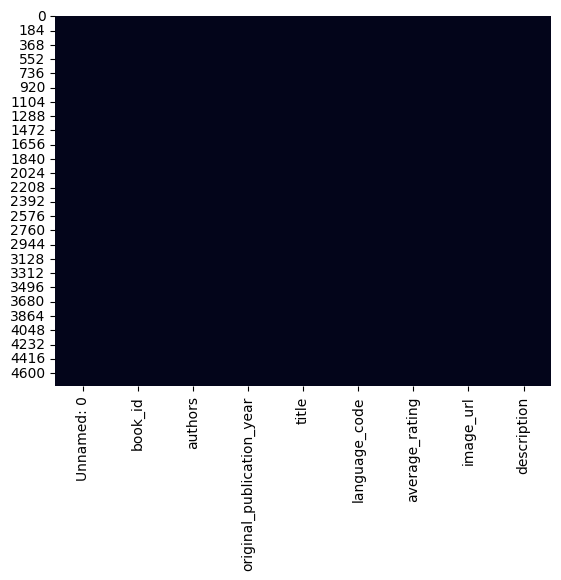

In [7]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

In [8]:
# Handle Missing Values
df = df.fillna("")

### Features Selection

In [9]:
# Select Important Features
selected_features = ['authors','title','language_code','description']
selected_features

['authors', 'title', 'language_code', 'description']

In [10]:
# Create Combined Features
df["combined_features"] = (df["authors"] + " " + df["title"] + " " + df["language_code"] + " " + df["description"])

In [11]:
# Display Combined Features
df["combined_features"].head()

,combined_features
0,Suzanne Collins The Hunger Games (The Hunger G...
1,"J.K. Rowling, Mary GrandPré Harry Potter and t..."
2,"Stephenie Meyer Twilight (Twilight, #1) en-US ..."
3,Harper Lee To Kill a Mockingbird eng Harper Le...
4,F. Scott Fitzgerald The Great Gatsby eng The o...


## Convert Text into Numerical Data using TF-IDF

In [12]:
# Convert Text into Numerical Data using TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
feature_vectors = tfidf.fit_transform(df["combined_features"])

In [13]:
print(feature_vectors)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 346170 stored elements and shape (4766, 38482)>
  Coords	Values
  (0, 33484)	0.13161677514690878
  (0, 6826)	0.1295979867208888
  (0, 16445)	0.44839835829664715
  (0, 14092)	0.5182688128042285
  (0, 11524)	0.026379941035541997
  (0, 15059)	0.10649946599108906
  (0, 4683)	0.10531259133527472
  (0, 35261)	0.07343324811429046
  (0, 30655)	0.07087370826929532
  (0, 8689)	0.06333208484664643
  (0, 36847)	0.11017708319153806
  (0, 23104)	0.09811808328113025
  (0, 13985)	0.07497377127220256
  (0, 34235)	0.08901941450255539
  (0, 27659)	0.10187654648076089
  (0, 35512)	0.09619557689850651
  (0, 33740)	0.09752185120929123
  (0, 25658)	0.1479487635063743
  (0, 4576)	0.10212104704761908
  (0, 14518)	0.0919157940918933
  (0, 13476)	0.085600404046791
  (0, 2114)	0.12528997290925703
  (0, 20052)	0.08258419199521196
  (0, 12085)	0.1129230120582841
  (0, 5251)	0.08221407060547498
  :	:
  (4765, 16574)	0.07327058089932073
  (4765, 221)	0.065

In [14]:
# Display Feature Vector Shape
feature_vectors.shape

(4766, 38482)

In [15]:
# Calculate Cosine Similarity
similarity = cosine_similarity(feature_vectors)
print(similarity)

[[1.00000000e+00 1.11946763e-03 2.44465216e-02 ... 7.33610068e-04
  1.34240813e-02 5.60088018e-03]
 [1.11946763e-03 1.00000000e+00 0.00000000e+00 ... 1.18012819e-03
  1.00065971e-02 3.92146626e-03]
 [2.44465216e-02 0.00000000e+00 1.00000000e+00 ... 3.08162632e-02
  2.66226397e-03 8.78982203e-03]
 ...
 [7.33610068e-04 1.18012819e-03 3.08162632e-02 ... 1.00000000e+00
  1.40634240e-02 1.24228150e-02]
 [1.34240813e-02 1.00065971e-02 2.66226397e-03 ... 1.40634240e-02
  1.00000000e+00 2.07075376e-02]
 [5.60088018e-03 3.92146626e-03 8.78982203e-03 ... 1.24228150e-02
  2.07075376e-02 1.00000000e+00]]


In [16]:
# Display Similarity Matrix Shape
similarity.shape

(4766, 4766)

## **Recommendation Function**

In [17]:
# Create Book Recommendation Function
from difflib import get_close_matches

def recommend(book_name, n=10):
    book_name = book_name.lower().strip()
    matched_books = df[df["title"].str.lower().str.contains(book_name, na=False)]

    if len(matched_books) > 0:
        index = matched_books.index[0]
    else:
        closest = get_close_matches(book_name, df["title"].tolist(), n=1, cutoff=0.4)

        if len(closest) == 0:
            return {
                "status": "Book Not Found",
                "books": None
            }

        print(f"\nShowing results for: {closest[0]}")
        index = df[df["title"] == closest[0]].index[0]
    similarity_score = list(enumerate(similarity[index]))
    sorted_books = sorted(similarity_score,
                          key=lambda x: x[1],
                          reverse=True)

    recommendations = []

    for book in sorted_books[1:n+1]:
        book_index = book[0]
        recommendations.append({
            "title": df.iloc[book_index]["title"],
            "author": df.iloc[book_index]["authors"],
            "language": df.iloc[book_index]["language_code"],
            "rating": df.iloc[book_index]["average_rating"],
            "similarity": round(book[1], 3)
        })

    return {
        "status": "Top Recommended Books",
        "books": recommendations
    }

## **Output**

In [18]:
# Book Name
book_name = input("Enter Book Name: ")
result = recommend(book_name)

print("\n", result["status"])
print("=" * 60)

if result["books"] is not None:
    for i, book in enumerate(result["books"], 1):
        print(f"\nBook {i}")
        print("-" * 40)
        print("Title      :", book["title"])
        print("Author     :", book["author"])
        print("Language   :", book["language"])
        print("Rating     :", book["rating"])
        print("Similarity :", book["similarity"])
else:
    print("No matching book found.")

Enter Book Name: harry potter

 Top Recommended Books

Book 1
----------------------------------------
Title      : Harry Potter Boxset (Harry Potter, #1-7)
Author     : J.K. Rowling
Language   : eng
Rating     : 4.74
Similarity : 0.495

Book 2
----------------------------------------
Title      : Harry Potter and the Deathly Hallows (Harry Potter, #7)
Author     : J.K. Rowling, Mary GrandPré
Language   : eng
Rating     : 4.61
Similarity : 0.43

Book 3
----------------------------------------
Title      : Harry Potter and the Half-Blood Prince (Harry Potter, #6)
Author     : J.K. Rowling, Mary GrandPré
Language   : eng
Rating     : 4.54
Similarity : 0.38

Book 4
----------------------------------------
Title      : Harry Potter Boxed Set, Books 1-5 (Harry Potter, #1-5)
Author     : J.K. Rowling, Mary GrandPré
Language   : eng
Rating     : 4.77
Similarity : 0.378

Book 5
----------------------------------------
Title      : Harry Potter and the Order of the Phoenix (Harry Potter, #5)
Au